## Introduction

The Israel–Hamas war has been one of the most heavily covered global conflicts in recent years, but despite reporting on the same events, news outlets often present those events in very different ways. This project explores how media framing shapes public understanding of war by analyzing differences in language, topic emphasis, and sentiment across major news organizations covering the conflict during **October 2023**, the first month of the war following the October 7 Hamas attacks.

My central thesis is that **news outlets frame the same conflict differently by emphasizing different topics, using different emotional tones, and choosing politically significant language in ways that shape audience perception**. Rather than asking whether coverage is simply “biased,” this project investigates *how* framing occurs through measurable patterns in word choice, topic distribution, and sentiment.

To test this, I built a corpus of **300 news articles**, evenly distributed across five major outlets, with **60 articles per outlet**. The outlets included:

* **Fox News** — chosen for its strong U.S. conservative perspective and security-focused framing
* **CNN** — chosen as a major U.S. mainstream outlet for comparison
* **BBC** — chosen for its international public-service journalism perspective
* **Al Jazeera** — chosen for its extensive Middle East coverage and humanitarian-centered reporting
* **The Times of Israel** — chosen for its direct Israeli perspective and close proximity to the conflict

These outlets were intentionally selected to represent a wide range of political, geographic, and editorial positions.

To create the dataset, I manually collected article headlines and URLs from each outlet, focusing specifically on articles published in **October 2023** related to the Israel–Hamas war. I then manually built a spreadsheet to organize the corpus, with the following columns:

* **Source** (news outlet name)
* **Date** (publication date)
* **Headline** (article title)
* **Topic** (my manually assigned topic category)
* **URL** (article link)
* **Full Article Text** (article body content)

The **Full Article Text** column was initially left blank for all outlets except **The Times of Israel**. Using Python and **BeautifulSoup**, I wrote outlet-specific scraping functions that pulled article body text directly from each article’s URL and stored it back into the dataframe. This allowed the dataset to be expanded from headline metadata into full-text corpora for analysis. The only exception was **The Times of Israel**, whose website blocked automated scraping, requiring all 60 article bodies to be manually copied and entered into the spreadsheet by hand. While more time-intensive, this ensured the dataset remained balanced and complete across all five outlets.

The decision to manually construct the spreadsheet and combine it with custom scraping allowed me to maintain control over article selection, remove duplicates, and ensure an even distribution of coverage across outlets. This was especially important for making fair comparisons.

To analyze the corpus, I used several Natural Language Processing (NLP) techniques. First, I cleaned and tokenized the article text by removing punctuation, stop words, and unnecessary formatting, followed by lemmatization to normalize word forms. From there, I conducted **word frequency analysis**, **keyword-specific comparisons**, **sentiment analysis**, and **LDA topic modeling** to identify patterns in both human-coded and machine-generated themes. By combining close reading with computational methods, this project aims to show how media outlets not only report on war differently, but actively construct different versions of the same conflict through framing.

In [51]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import time

# import premade csv as dataframe

df = pd.read_csv("news_articles.csv")

headers = {
    "User-Agent": "Mozilla/5.0"
}

In [53]:
# scan each url column to begin text retrieval
def get_soup(url):
    response = requests.get(url, headers=headers, timeout=15)
    response.raise_for_status()
    return BeautifulSoup(response.text, "html.parser")

In [54]:
# convert html tags into string text
def elements_to_text(elements, junk_phrases=None):
    clean_paragraphs = []

    if junk_phrases is None:
        junk_phrases = []

    for element in elements:
        text = element.get_text(" ", strip=True)

        if not text:
            continue

        is_junk = False

        for phrase in junk_phrases:
            if phrase in text:
                is_junk = True

        if not is_junk:
            clean_paragraphs.append(text)

    return " ".join(clean_paragraphs)

In [55]:
# Scraper functions for each outlet

def scrape_cnn(url):
    soup = get_soup(url)
    article_content = soup.find("div", class_="article__content")

    if article_content is None:
        return ""

    elements = article_content.find_all(["p", "li", "h2", "h3"])
    return elements_to_text(elements)


def scrape_bbc(url):
    soup = get_soup(url)
    article_content = soup.find("article")

    if article_content is None:
        return ""

    elements = article_content.find_all(["p", "li", "h2", "h3"])
    return elements_to_text(elements)


def scrape_aljazeera(url):
    soup = get_soup(url)
    article_content = soup.find("div", class_="wysiwyg wysiwyg--all-content")

    if article_content is None:
        return ""

    elements = article_content.find_all(["p", "li", "h2", "h3"])
    return elements_to_text(elements)


def scrape_fox(url):
    soup = get_soup(url)
    article_content = soup.find("div", class_="article-body")

    if article_content is None:
        return ""

    elements = article_content.find_all(["p", "li"])

    junk_phrases = [
        "CLICK HERE TO GET THE FOX NEWS APP",
        "The Associated Press contributed to this report.",
        "LIVE UPDATES",
        "FOX News Live",
    ]

    return elements_to_text(elements, junk_phrases)

In [56]:
# Choose scraper based on Source

def scrape_article(row):
    source = row["Source"]
    url = row["URL"]

    existing_text = row.get("Full Article Text", "")

    if source == "Times of Israel":
        return existing_text

    if source == "CNN":
        return scrape_cnn(url)

    elif source == "BBC":
        return scrape_bbc(url)

    elif source == "Al Jazeera":
        return scrape_aljazeera(url)

    elif source == "Fox News":
        return scrape_fox(url)

    else:
        return ""

In [57]:
# Scrape and save text into dataframe

if "Full Article Text" not in df.columns:
    df["Full Article Text"] = ""

for index, row in df.iterrows():
    current_text = str(row["Full Article Text"])

    if current_text != "" and current_text != "nan":
        continue

    try:
        print("Scraping row", index, row["Source"])

        article_text = scrape_article(row)

        df.loc[index, "Full Article Text"] = article_text

        time.sleep(1)

    except Exception as e:
        print("FAILED row", index)
        print(row["URL"])
        print(e)

        df.loc[index, "Full Article Text"] = ""

Scraping row 0 CNN
Scraping row 1 CNN
Scraping row 2 CNN
Scraping row 3 CNN
Scraping row 4 CNN
Scraping row 5 CNN
Scraping row 6 CNN
Scraping row 7 CNN
Scraping row 8 CNN
Scraping row 9 CNN
Scraping row 10 CNN
Scraping row 11 CNN
Scraping row 12 CNN
Scraping row 13 CNN
Scraping row 14 CNN
Scraping row 15 CNN
Scraping row 16 CNN
Scraping row 17 CNN
Scraping row 18 CNN
Scraping row 19 CNN
Scraping row 20 CNN
Scraping row 21 CNN
Scraping row 22 CNN
Scraping row 23 CNN
Scraping row 24 CNN
Scraping row 25 CNN
Scraping row 26 CNN
Scraping row 27 CNN
Scraping row 28 CNN
Scraping row 29 CNN
Scraping row 30 CNN
Scraping row 31 CNN
Scraping row 32 CNN
Scraping row 33 CNN
Scraping row 34 CNN
Scraping row 35 CNN
Scraping row 36 CNN
Scraping row 37 CNN
Scraping row 38 CNN
Scraping row 39 CNN
Scraping row 40 CNN
Scraping row 41 CNN
Scraping row 42 CNN
Scraping row 43 CNN
Scraping row 44 CNN
Scraping row 45 CNN
Scraping row 46 CNN
Scraping row 47 CNN
Scraping row 48 CNN
Scraping row 49 CNN
Scraping r

In [61]:
# Save dataframe with full text
from google.colab import files

missing_count = df["Full Article Text"].isna().sum() + (df["Full Article Text"] == "").sum()

if missing_count == 0:
    df.to_csv("news_articles_with_text.csv", index=False)
    print("Success: all article texts scraped and saved. Downloading completed dataset now...")
    files.download("news_articles_with_text.csv")
else:
    print("Still missing", missing_count, "articles.")

Success: all article texts scraped and saved. Downloading completed dataset now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
# Clean article text
import re

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text)

    text = re.sub(r"\s+", " ", text)   # normalize whitespace
    text = text.strip()                # remove edge spaces

    return text

In [64]:
# Save cleaned text into a new dataframe column
df["Clean Text"] = df["Full Article Text"].apply(clean_text)

print(df[["Full Article Text", "Clean Text"]].head())

                                   Full Article Text  \
0  Israel’s Prime Minister Benjamin Netanyahu dec...   
1  Hamas captured a number of Israelis during its...   
2  The rockets began around 6:30 a.m., Tal Gibly ...   
3  When the Palestinian militant group Hamas laun...   
4  Israel’s Prime Minister Benjamin Netanyahu sai...   

                                          Clean Text  
0  Israel’s Prime Minister Benjamin Netanyahu dec...  
1  Hamas captured a number of Israelis during its...  
2  The rockets began around 6:30 a.m., Tal Gibly ...  
3  When the Palestinian militant group Hamas laun...  
4  Israel’s Prime Minister Benjamin Netanyahu sai...  


In [66]:
# Tokenize cleaned text and save into dataframe
import nltk
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("punkt_tab")

df["Tokens"] = df["Clean Text"].apply(word_tokenize)

print(df["Tokens"].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


0    [Israel, ’, s, Prime, Minister, Benjamin, Neta...
1    [Hamas, captured, a, number, of, Israelis, dur...
2    [The, rockets, began, around, 6:30, a.m., ,, T...
3    [When, the, Palestinian, militant, group, Hama...
4    [Israel, ’, s, Prime, Minister, Benjamin, Neta...
Name: Tokens, dtype: object


In [185]:
# Cleaning the tokens

from nltk.corpus import stopwords
from string import punctuation

nltk.download('stopwords')

# curated stop word list from iterations of word freq output

myStopWords = ["cnn","bbc","fox","news",
               "also","said","says","say",
               "told","according","us","would",
               "take", "taken","one","october",
               "oct","list","day", "getty", "ap"]

StopWords = list(punctuation) + stopwords.words('english') + myStopWords

def filter_tokens(tokens):

    clean_tokens = []

    for word in tokens:

        # remove punctuation at beginning/end
        word = re.sub(r"(^[^\w]+|[^\w]+$)", "", word)

        # lowercase after cleaning
        word = word.lower()

        # only append if word is not empty and not a stopword and not a digit
        if word and word not in StopWords and not word.isdigit():
            clean_tokens.append(word)

    return clean_tokens

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [186]:
# Save cleaned tokens into dataframe
df["Filtered Tokens"] = df["Tokens"].apply(filter_tokens)

print(df["Filtered Tokens"].head())

0    [israel, prime, minister, benjamin, netanyahu,...
1    [hamas, captured, number, israelis, deadly, at...
2    [rockets, began, around, 6:30, a.m, tal, gibly...
3    [palestinian, militant, group, hamas, launched...
4    [israel, prime, minister, benjamin, netanyahu,...
Name: Filtered Tokens, dtype: object


#Beginning Text Anaylsis with Word Count Comparisons

In [160]:
df["Raw Word Count"] = df["Tokens"].apply(len)

display(df.groupby("Source")["Raw Word Count"].mean())


,Raw Word Count
Source,
Al Jazeera,870.966667
BBC,1084.450000
CNN,1416.283333
Fox News,831.900000
The Times of Israel,1132.383333


From the Raw Word Count data set, we find that CNN has the highest average word count per article whereas Fox News has the least.

In [187]:
df["Cleaned Word Count"] = df["Filtered Tokens"].apply(len)

display(df.groupby("Source")["Cleaned Word Count"].mean())

,Cleaned Word Count
Source,
Al Jazeera,412.433333
BBC,504.250000
CNN,666.116667
Fox News,402.933333
The Times of Israel,532.800000


For consistency, I also compared the average word count of each outlet after cleaning the text, including the removal of stop words. The results show that CNN still has the highest average word count, while Fox News continues to have the smallest corpus. This suggests that removing stop words did not significantly change the proportional size of each outlet’s content.

In [180]:
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [188]:
# Lemmatizing tokens
def lemmatize_tokens(tokens):

    lemmatized_tokens = []

    for word in tokens:

        lemma = lemmatizer.lemmatize(word)

        lemmatized_tokens.append(lemma)

    return lemmatized_tokens

In [189]:
# Saving lemmatized tokens into dataframe
df["Lemmatized Tokens"] = df["Filtered Tokens"].apply(lemmatize_tokens)

print(df["Lemmatized Tokens"].head())

0    [israel, prime, minister, benjamin, netanyahu,...
1    [hamas, captured, number, israeli, deadly, att...
2    [rocket, began, around, 6:30, a.m, tal, gibly,...
3    [palestinian, militant, group, hamas, launched...
4    [israel, prime, minister, benjamin, netanyahu,...
Name: Lemmatized Tokens, dtype: object


# Word Frequency Analysis by News Outlet

The best way to begin proving my thesis is by comparing their most frequent words.

In [190]:
from collections import Counter

fox_words = df[df["Source"] == "Fox News"]["Lemmatized Tokens"].sum()
cnn_words = df[df["Source"] == "CNN"]["Lemmatized Tokens"].sum()
bbc_words = df[df["Source"] == "BBC"]["Lemmatized Tokens"].sum()
aj_words = df[df["Source"] == "Al Jazeera"]["Lemmatized Tokens"].sum()
toi_words = df[df["Source"] == "The Times of Israel"]["Lemmatized Tokens"].sum()

print("Fox:", Counter(fox_words).most_common(20))
print("CNN:", Counter(cnn_words).most_common(20))
print("BBC:", Counter(bbc_words).most_common(20))
print("Al Jazeera:", Counter(aj_words).most_common(20))
print("TOI:", Counter(toi_words).most_common(20))

Fox: [('israel', 612), ('gaza', 595), ('hamas', 590), ('israeli', 463), ('attack', 223), ('palestinian', 219), ('terrorist', 195), ('people', 175), ('strip', 158), ('war', 155), ('force', 144), ('image', 135), ('civilian', 132), ('hostage', 128), ('rocket', 126), ('saturday', 108), ('idf', 108), ('group', 107), ('military', 107), ('killed', 106)]
CNN: [('gaza', 842), ('israel', 816), ('hamas', 587), ('israeli', 510), ('palestinian', 362), ('people', 321), ('attack', 253), ('hospital', 217), ('hostage', 193), ('official', 189), ('idf', 180), ('civilian', 167), ('group', 159), ('killed', 159), ('two', 158), ('fuel', 157), ('militant', 153), ('war', 149), ('aid', 148), ('border', 145)]
BBC: [('gaza', 813), ('israel', 732), ('hamas', 502), ('israeli', 449), ('palestinian', 279), ('people', 271), ('attack', 250), ('war', 195), ('killed', 172), ('strike', 171), ('military', 168), ('hostage', 158), ('hospital', 143), ('civilian', 118), ('border', 106), ('conflict', 94), ('air', 92), ('two', 9

In [193]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_top_words(words, title):

    top_words = Counter(words).most_common(20)

    bar_labels = []
    counts = []

    for word, count in top_words:
        bar_labels.append(word)
        counts.append(count)

    plt.figure(figsize=(14, 6))

    bars = plt.bar(bar_labels, counts)

    plt.title(title)
    plt.xlabel("Words")
    plt.ylabel("Frequency")

    plt.xticks(rotation=45, ha="right")

    # add numbers on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            str(height),
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()

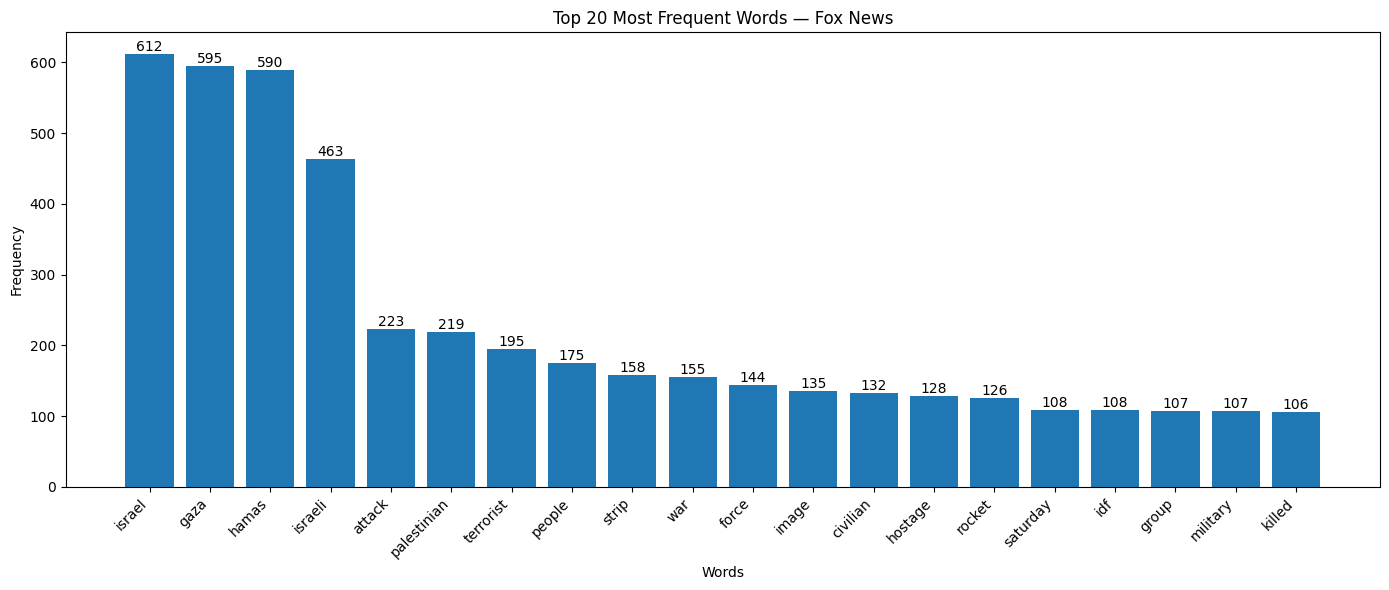

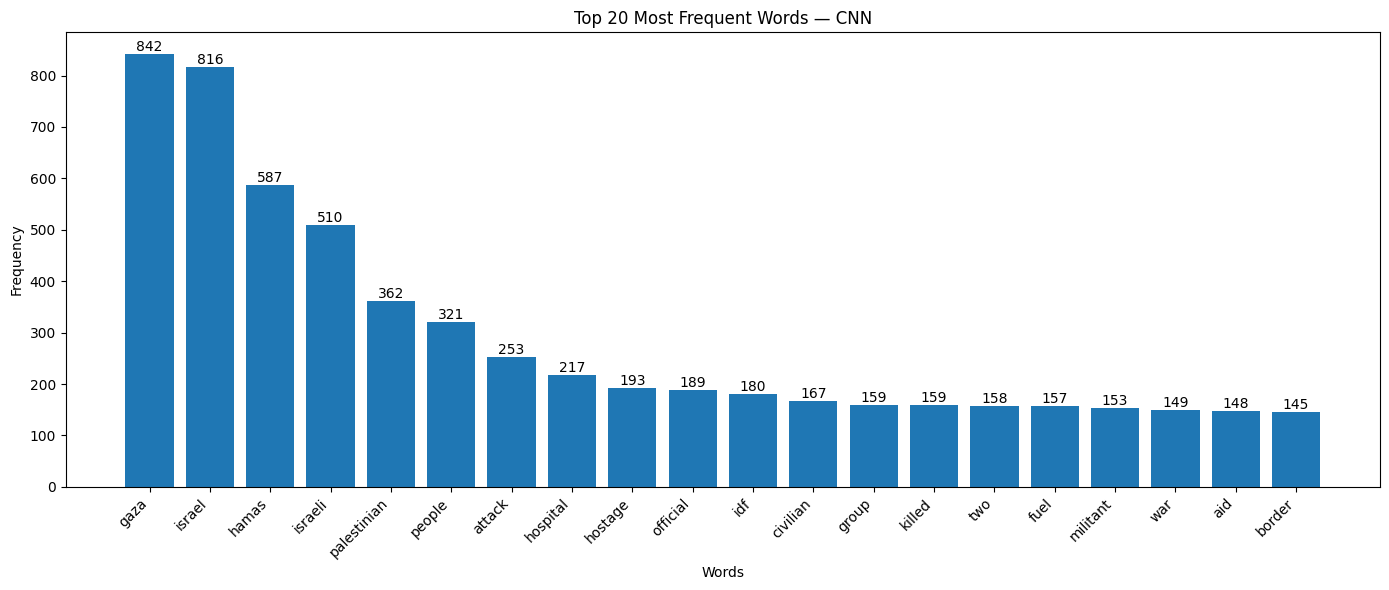

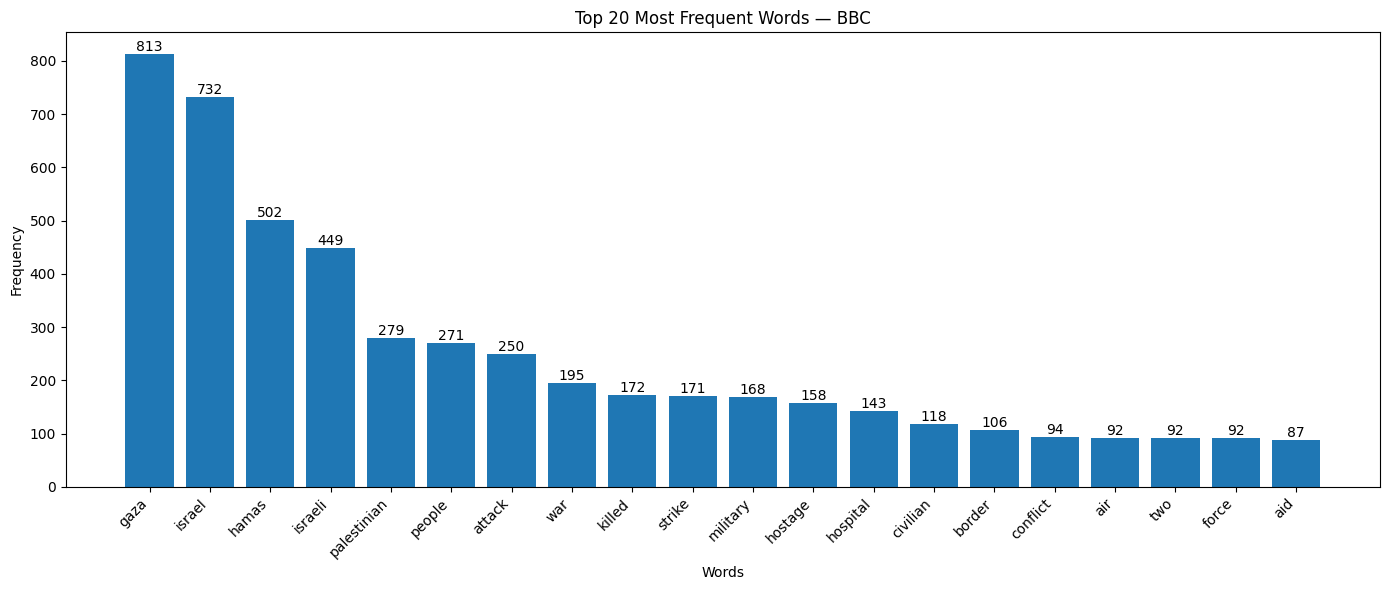

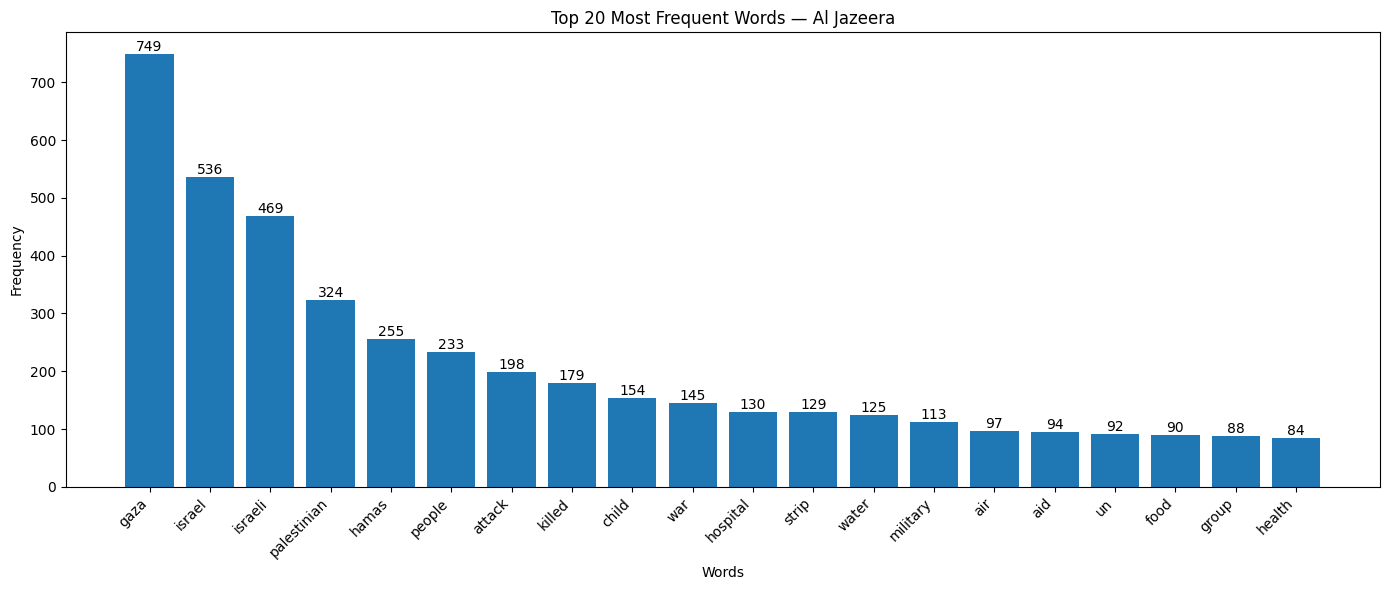

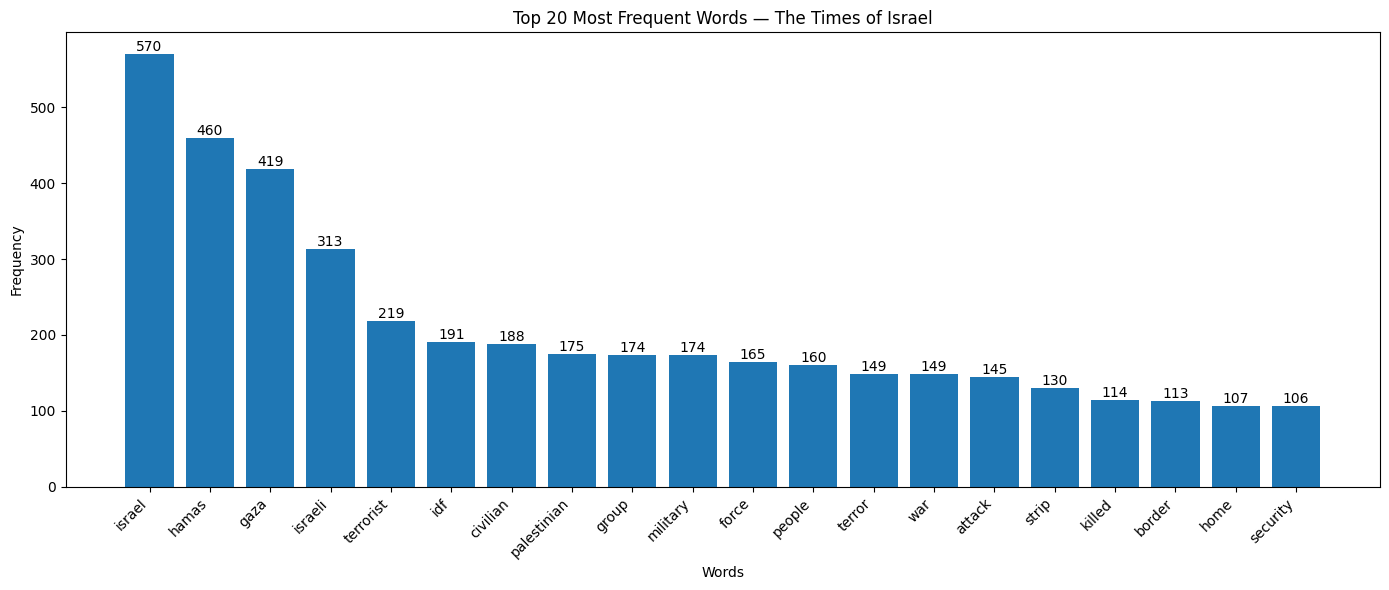

In [194]:
plot_top_words(fox_words, "Top 20 Most Frequent Words — Fox News")
plot_top_words(cnn_words, "Top 20 Most Frequent Words — CNN")
plot_top_words(bbc_words, "Top 20 Most Frequent Words — BBC")
plot_top_words(aj_words, "Top 20 Most Frequent Words — Al Jazeera")
plot_top_words(toi_words, "Top 20 Most Frequent Words — The Times of Israel")

In [174]:
!pip install wordcloud
from wordcloud import WordCloud

In [191]:
def make_wordcloud(words, title):

    text = " ".join(words)

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(15, 8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

In [192]:
make_wordcloud(fox_words, "Fox News Word Cloud")
make_wordcloud(cnn_words, "CNN Word Cloud")
make_wordcloud(bbc_words, "BBC Word Cloud")
make_wordcloud(aj_words, "Al Jazeera Word Cloud")
make_wordcloud(toi_words, "The Times of Israel Word Cloud")

Output hidden; open in https://colab.research.google.com to view.

#Word Clouds Are Fun

## Does Each News Outlet Acknowledge Distinctive Sensitive Keywords?

Beyond broad word frequency, I wanted to examine whether each news outlet used certain highly sensitive and politically meaningful keywords that stood out during my close reading of the dataset. These words were chosen because they represent some of the most contested and emotionally charged aspects of the conflict, and their presence (or absence) may reveal important differences in framing.

1. **Terrorist**
   One major question is whether outlets explicitly refer to Hamas as a *terrorist* group. During data collection, I noticed that outlets varied in how they described Hamas, with terms like *militant*, *group*, or *terrorist* carrying very different political and emotional weight.

2. **Child / Children**
   This keyword helps measure whether outlets emphasize child casualties and civilian victims, which can signal a stronger humanitarian framing of the conflict.

3. **Hostages**
   This term highlights attention given to the Israeli hostage crisis following the October 7 attacks and whether outlets consistently center this aspect of the conflict.

4. **Hospital**
   This keyword captures whether outlets heavily covered the **Al-Ahli hospital blast**, one of the most controversial and highly disputed events in the media coverage during the early weeks of the war.

By isolating these keywords, I can more directly compare how each outlet chooses to emphasize certain realities of the war, further supporting my larger analysis of media framing.


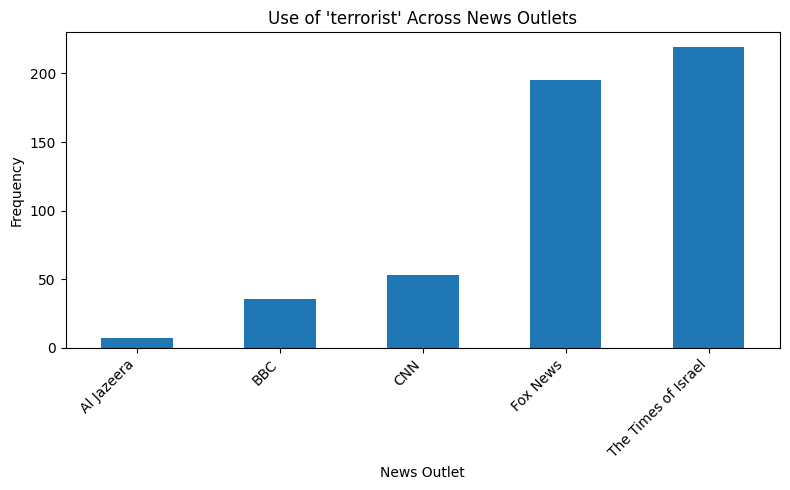

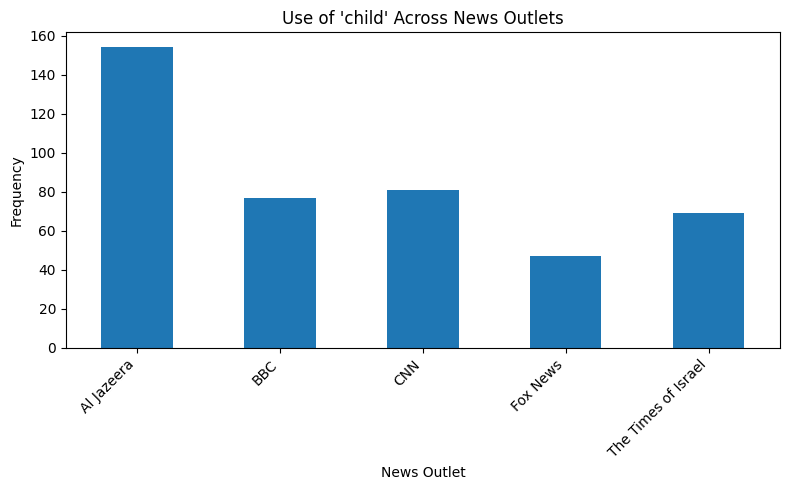

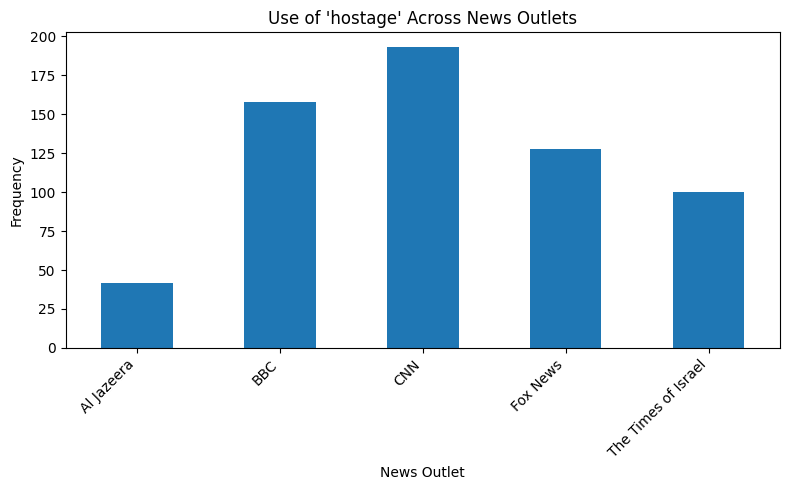

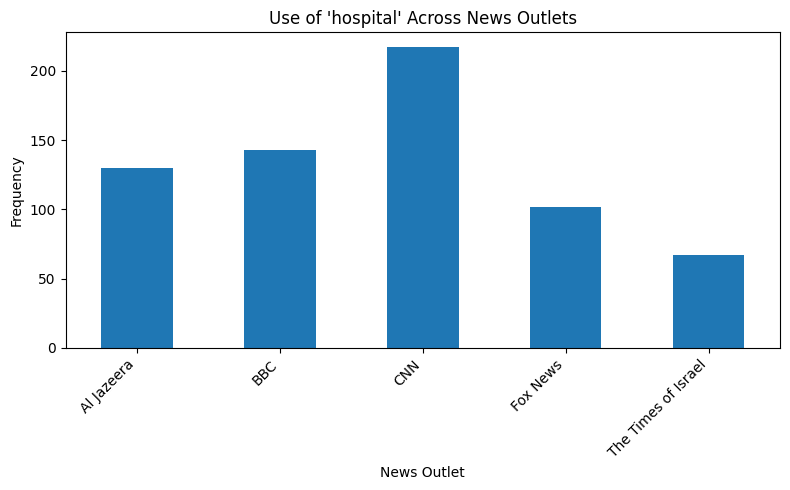

In [156]:
import matplotlib.pyplot as plt

keywords = ["terrorist", "child", "hostage", "hospital"]

def count_keyword(tokens, keyword):
    return tokens.count(keyword)

for keyword in keywords:
    df[keyword + "_count"] = df["Lemmatized Tokens"].apply(lambda tokens: count_keyword(tokens, keyword))

    keyword_counts = df.groupby("Source")[keyword + "_count"].sum()

    plt.figure(figsize=(8, 5))
    keyword_counts.plot(kind="bar")

    plt.title(f"Use of '{keyword}' Across News Outlets")
    plt.xlabel("News Outlet")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

## Interesting Findings from Keyword Frequency Analysis

* **The Times of Israel** mentioned *hospital* and hospital-related medical crises the least. This may suggest less emphasis on the **Al-Ahli hospital blast** and the broader medical crisis in Gaza compared to other outlets.

* **Al Jazeera** mentioned *child*/*children* the most, strongly reinforcing its humanitarian framing and its emphasis on Gaza civilian casualties, especially children.

* **Al Jazeera** mentioned *hostage* the least, which may reflect its stronger focus on Palestinian civilian suffering and humanitarian conditions rather than Israeli-centered narratives.

* Interestingly, **The Times of Israel** did **not** mention *hostages* the most, even though Israeli civilians were the primary victims of the hostage crisis. This may suggest that its coverage prioritized military operations and national security over continued hostage-focused reporting.

* **Fox News** mentioned *child*/*children* the least, which contrasts sharply with Al Jazeera and may suggest less focus on Palestinian civilian casualties.

* **Fox News** mentioned *terrorist* the most, which supports the idea that its coverage focused heavily on Hamas attacks, violence, and security framing.

* **Al Jazeera** mentioned *terrorist* the least, with **BBC** and **CNN** also using it less frequently. This suggests these outlets often used alternative terms such as *militant* or *group*, reflecting differences in political framing and language choice.

* Overall, these keyword differences reinforce the larger pattern seen throughout the project: each outlet not only covered different aspects of the war, but also used distinct language choices that shaped how audiences may interpret the conflict.


#LDA Topic Modeling Findings

In [199]:
!pip install gensim
from gensim import corpora, models
import gensim
from IPython.display import display, Markdown

In [204]:
docs = df["Lemmatized Tokens"].tolist()

dictionary = corpora.Dictionary(docs)

dictionary.filter_extremes(no_below=5, no_above=0.5)

print(len(dictionary))

3358


In [210]:
corpus = [dictionary.doc2bow(text) for text in docs]

ldamodel = gensim.models.ldamodel.LdaModel(
    corpus,
    num_topics=5,
    id2word=dictionary,
    passes=20,
    random_state=42
)

for topic in ldamodel.print_topics(num_topics=5, num_words=15):
    print("Topic", topic[0])
    print(topic[1])
    print()

Topic 0
0.012*"water" + 0.011*"aid" + 0.011*"humanitarian" + 0.011*"fuel" + 0.008*"crossing" + 0.008*"supply" + 0.007*"food" + 0.007*"egypt" + 0.007*"un" + 0.007*"health" + 0.006*"hospital" + 0.006*"enclave" + 0.005*"rafah" + 0.005*"territory" + 0.005*"international"

Topic 1
0.008*"video" + 0.008*"kibbutz" + 0.008*"soldier" + 0.007*"tunnel" + 0.006*"family" + 0.006*"militant" + 0.005*"body" + 0.005*"know" + 0.005*"saturday" + 0.005*"idf" + 0.004*"community" + 0.004*"rocket" + 0.004*"festival" + 0.004*"missing" + 0.004*"still"

Topic 2
0.008*"west" + 0.008*"bank" + 0.007*"security" + 0.006*"settler" + 0.006*"jewish" + 0.005*"government" + 0.005*"arab" + 0.005*"president" + 0.005*"state" + 0.004*"netanyahu" + 0.004*"member" + 0.004*"protest" + 0.004*"new" + 0.004*"violence" + 0.004*"country"

Topic 3
0.010*"idf" + 0.007*"operation" + 0.006*"defense" + 0.006*"biden" + 0.006*"rocket" + 0.006*"netanyahu" + 0.005*"hezbollah" + 0.005*"state" + 0.005*"iran" + 0.004*"saturday" + 0.004*"intelli

In [214]:
def get_main_topic(bow):
    topic_scores = ldamodel.get_document_topics(bow)
    main_topic = max(topic_scores, key=lambda x: x[1])[0]
    return main_topic

df["LDA Topic"] = [get_main_topic(bow) for bow in corpus]

In [216]:
lda_topic_labels = {
    0: "Humanitarian Aid / Gaza Conditions",
    1: "Hamas Attack / Hostages / Civilian Trauma",
    2: "Regional / Political Response",
    3: "Israeli Military / U.S. Security Response",
    4: "Al-Ahli Hospital Blast / Medical Crisis"
}

df["LDA Topic Label"] = df["LDA Topic"].map(lda_topic_labels)


# What the Topics Labels Seem to Be
LDA topic modeling does not automatically assign names to topics; instead, it generates clusters of high-probability words that must be interpreted by the researcher. In this project, I assigned labels by analyzing the relationships between each topic’s most important words and considering their context within October 2023 Israel–Gaza war coverage. Topic 0 was labeled “Humanitarian Aid / Siege Conditions” because its highest-weighted words such as water, aid, fuel, food, crossing, and Rafah center on survival resources, humanitarian access, and blockade conditions, specifically the importance of the Egypt-Gaza border (known as Rafah Crossing) and how it acted as life line for civilians in Gaza. Topic 1 was labeled “Hamas Attack / Hostages / Civilian Trauma” because words like kibbutz, festival, family, body, and missing strongly connect to the October 7 attacks and their immediate civilian aftermath. Topic 2 was labeled “Regional / Political Response” because terms like West Bank, settler, government, protest, and Arab point to broader political tensions, regional unrest, and developments outside of Gaza itself. Topic 3 was labeled “Israeli Military / U.S. Security Response” because it contains terms such as IDF, operation, defense, Biden, Hezbollah, and Iran, reflecting military strategy and international security alliances. Finally, Topic 4 was labeled “Al-Ahli Hospital Blast / Medical Crisis” because hospital was by far its strongest term, alongside blast, rocket, explosion, and evacuation, directly pointing to the heavy coverage surrounding the Al-Ahli hospital explosion and the larger medical emergency in Gaza.

In [217]:
lda_counts = pd.crosstab(
    df["Source"],
    df["LDA Topic Label"],
    normalize="index"
) * 100

display(Markdown("## LDA Topic Distribution by News Outlet (%)"))
display(lda_counts)

## LDA Topic Distribution by News Outlet (%)

LDA Topic Label,Al-Ahli Hospital Blast / Medical Crisis,Hamas Attack / Hostages / Civilian Trauma,Humanitarian Aid / Gaza Conditions,Israeli Military / U.S. Security Response,Regional / Political Response
Source,,,,,
Al Jazeera,15.000000,6.666667,56.666667,13.333333,8.333333
BBC,23.333333,26.666667,20.000000,11.666667,18.333333
CNN,5.000000,15.000000,40.000000,28.333333,11.666667
Fox News,10.000000,6.666667,8.333333,63.333333,11.666667
The Times of Israel,6.666667,26.666667,15.000000,31.666667,20.000000


#Distribution Explanation
The LDA topic distribution further supports my thesis that news outlets framed the Israel–Hamas war differently by emphasizing different aspects of the conflict. **Al Jazeera** overwhelmingly concentrated on **Humanitarian Aid / Gaza Conditions** (56.7%), reinforcing its strong focus on civilian suffering, resource shortages, and life under siege. **Fox News**, by contrast, heavily emphasized **Israeli Military / U.S. Security Response** (63.3%), showing a much stronger focus on military operations, defense strategy, and allied security concerns. **CNN** presented a more mixed distribution but leaned toward humanitarian conditions (40%) and military response (28.3%), suggesting a balance between civilian impact and strategic developments. **BBC** displayed the most evenly distributed coverage, with significant attention to the **Al-Ahli Hospital Blast**, **Hamas attacks and hostages**, and broader humanitarian issues, reflecting a more event-centered and broad reporting style. **The Times of Israel** focused most on **Israeli military response** (31.7%) and **Hamas attacks/hostages** (26.7%), aligning closely with its position as an Israeli outlet directly covering the attack’s impact on Israeli civilians and security. Overall, the topic model shows that although all outlets covered the same war, they consistently prioritized different themes, revealing distinct framing patterns shaped by editorial focus and audience perspective.


#How does LDA compare to my human-selected topic distribution?
Before running LDA, I manually assigned a topic to each news article based on my own interpretation of its content. I grouped the articles into five categories based on what I observed to be the most common and most distinct forms of coverage across the dataset. These categories were created through close reading of the headlines and article texts, allowing me to establish a means for comparison before applying computational analysis.

The five manually assigned categories were:

1. Hamas Attack / Hamas Operations
2. Hostages
3. Humanitarian
4. International Response
5. Israeli Response

After running LDA, the machine-generated topics closely aligned with these categories, despite being created entirely from patterns in word usage rather than human interpretation. This suggests that the themes I identified manually were strongly reflected in the language of the corpus itself. The overlap between my human-interperted topics and the LDA-generated topics strengthens the reliability of my analysis, showing that both close reading and computational modeling point toward similar thematic patterns in how the Israel–Hamas war was covered across different news outlets.


Below is a distribution table of my human-selected topics.



In [218]:
topic_counts = pd.crosstab(df["Source"], df["Topic"], normalize="index") * 100

display(Markdown("## My Human Topic Distribution by News Outlet (%)"))
display(topic_counts)

## My Human Topic Distribution by News Outlet (%)

Topic,Hamas Attack / Hamas Operations,Hostages,Humanitarian,International Response,Israeli Response
Source,,,,,
Al Jazeera,11.666667,5.000000,61.666667,13.333333,8.333333
BBC,15.000000,3.333333,41.666667,13.333333,26.666667
CNN,15.000000,15.000000,33.333333,25.000000,11.666667
Fox News,23.333333,15.000000,15.000000,21.666667,25.000000
The Times of Israel,25.000000,10.000000,18.333333,18.333333,28.333333


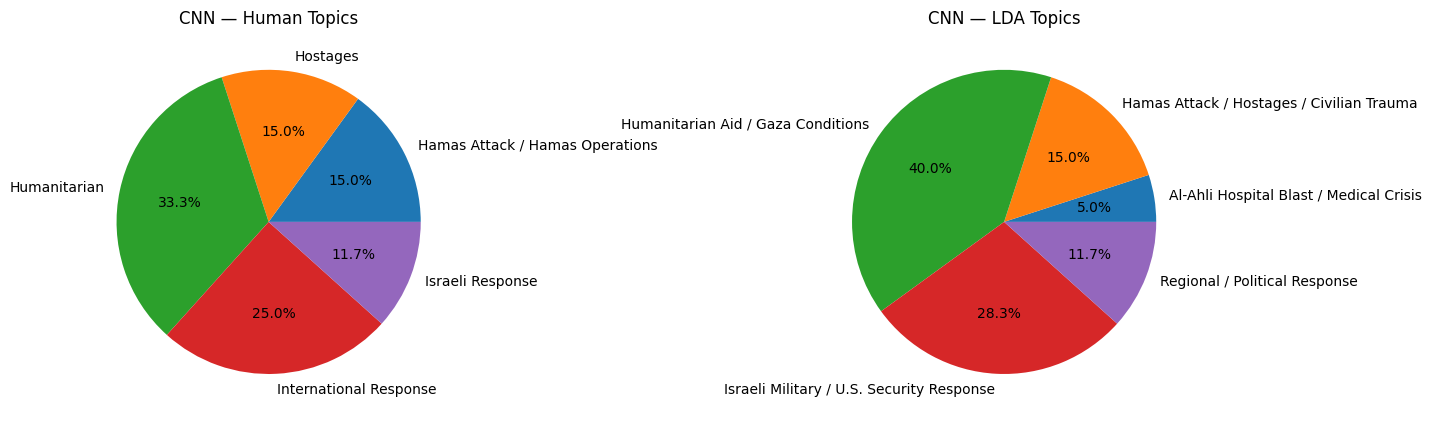

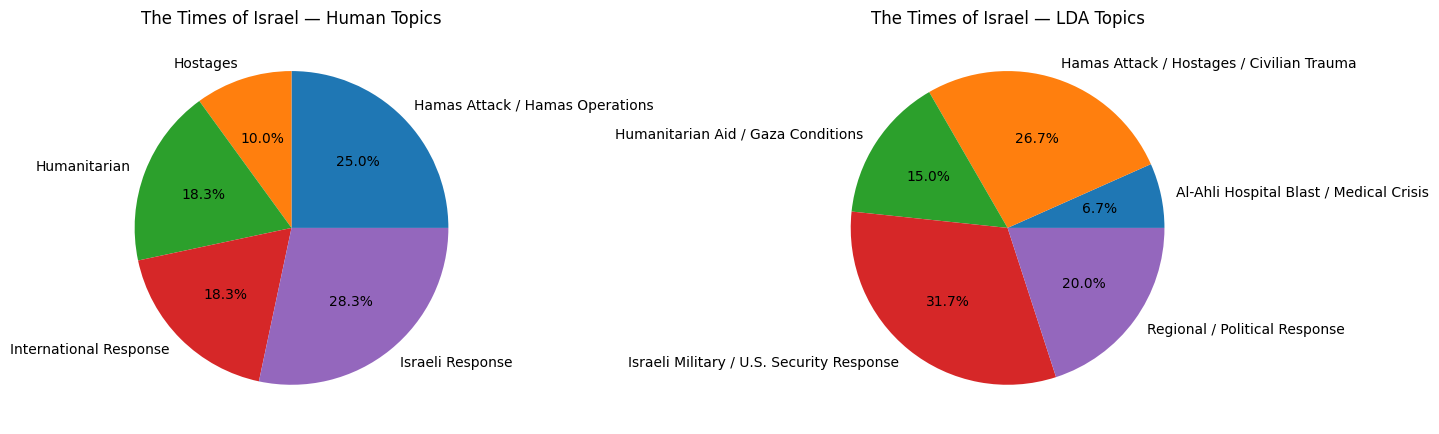

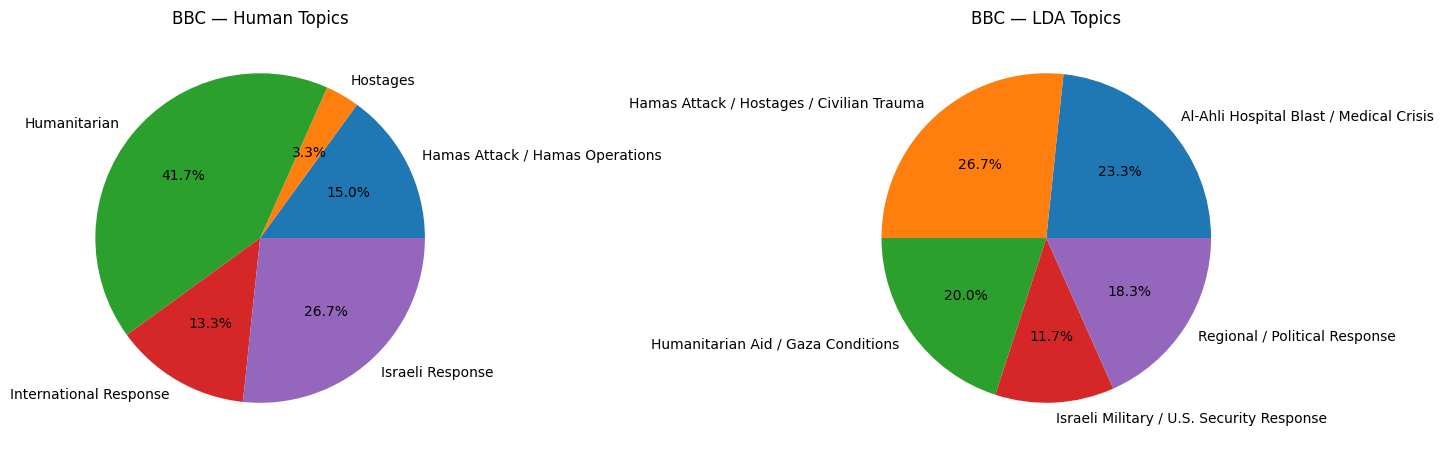

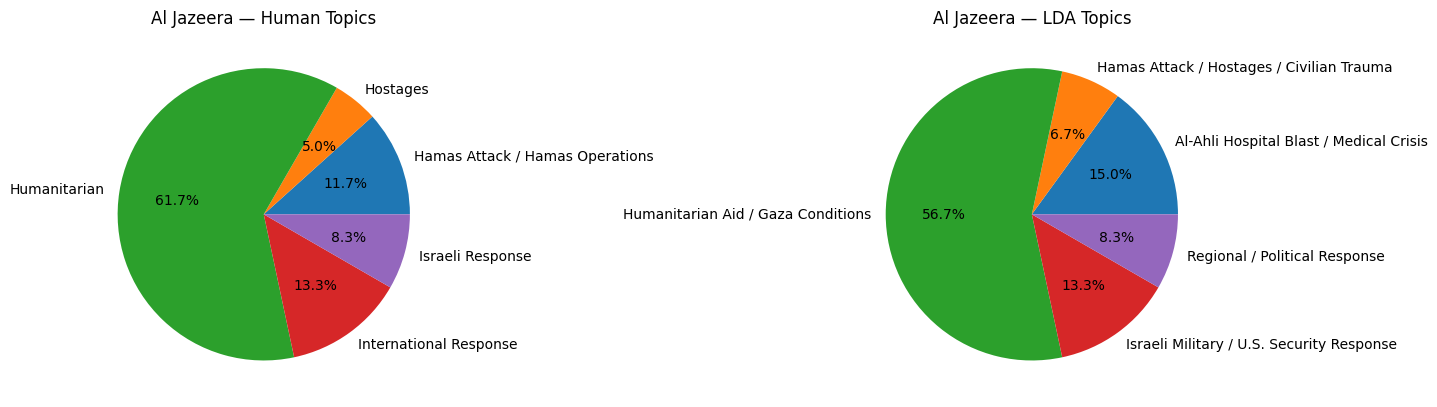

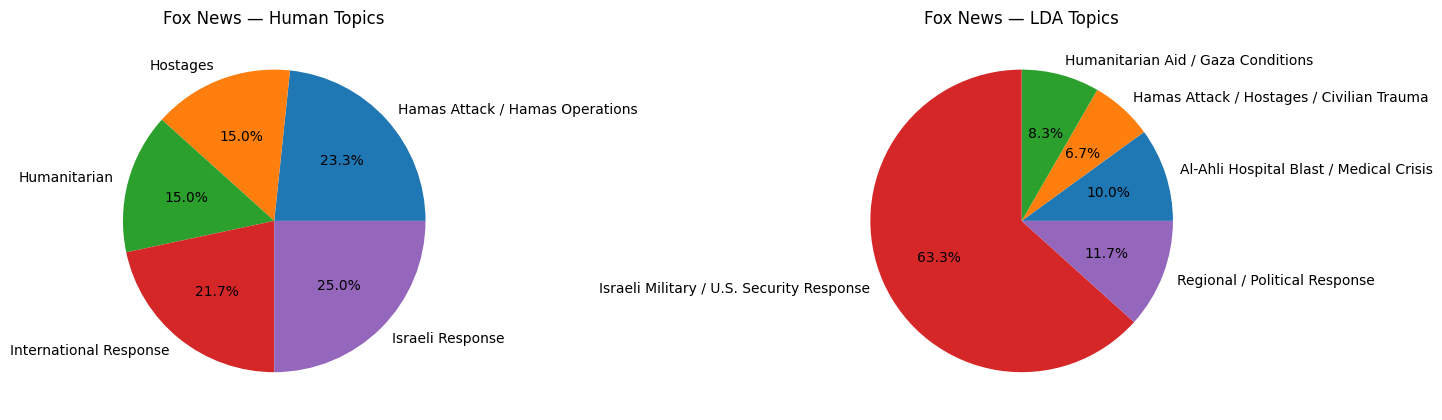

In [220]:
sources = df["Source"].unique()

for source in sources:

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Human topics
    topic_counts.loc[source].plot(
        kind="pie",
        autopct="%1.1f%%",
        ax=axes[0]
    )
    axes[0].set_title(f"{source} — Human Topics")
    axes[0].set_ylabel("")

    # LDA topics
    lda_counts.loc[source].plot(
        kind="pie",
        autopct="%1.1f%%",
        ax=axes[1]
    )
    axes[1].set_title(f"{source} — LDA Topics")
    axes[1].set_ylabel("")

    plt.tight_layout()
    plt.show()

Comparing my manually assigned topics with the LDA-generated topics shows strong overall alignment. In both models, Al Jazeera remained heavily focused on humanitarian coverage, reinforcing its emphasis on civilian suffering and aid conditions. Fox News and The Times of Israel also showed consistent focus on military and U.S. allied security coverage, though LDA grouped these themes more heavily into broader military-response categories as I grouped any action/actor outside of Gaza-Israel as an International Response/Responder.

The biggest differences appeared with BBC and CNN, where LDA broke down some of my broader human-assigned categories into more event-specific themes, such as the Al-Ahli hospital blast. On the other hand, I assigned a distinct topic for hostage-related coverage, where LDA seemed to group that into the general Hamas Operations / Attacks / Cilvian Trauma. This suggests that while my manual assignment captured the general themes of each article, LDA revealed how certain major events dominated the language within those categories.

Overall, the overlap between both methods strengthens the reliability of my findings. Both human interpretation and computational modeling point to the same larger conclusion: each outlet consistently emphasized different aspects of the war, supporting my thesis that media framing shapes how conflict is presented to audiences.

#Sentiment Analysis

Sentiment analysis is an important part of this project because it helps measure the emotional tone of how each outlet reports on the Israel–Hamas war. While topic modeling and word frequency show what each outlet focuses on, sentiment analysis helps show how those topics are framed. This is especially important for my thesis because differences in emotional tone can reveal bias, emphasis, and framing strategies across news outlets. For example, an outlet may focus heavily on humanitarian suffering while using highly negative language, or another may focus on military response using language tied to security and defense. By comparing sentiment across both topics and outlets, I can better understand not just the content being reported, but the emotional framing used to shape audience perception of the conflict.


In [163]:
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

df["Sentiment"] = df["Clean Text"].apply(lambda text: sia.polarity_scores(text)["compound"])

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [168]:
display(Markdown("## Sentiment Analysis by News Outlet"))
display(df.groupby("Source")["Sentiment"].mean())

## Sentiment Analysis by News Outlet

,Sentiment
Source,
Al Jazeera,-0.921590
BBC,-0.961682
CNN,-0.820195
Fox News,-0.928752
The Times of Israel,-0.837187


# Explaining Sentiment Analysis Findings by News Outlet

The sentiment analysis shows that all five news outlets had strongly negative sentiment overall, which is expected given the violent and tragic nature of the Israel–Hamas war. However, there are still noticeable differences in intensity. **BBC** had the most negative average sentiment (-0.962), followed closely by **Fox News** (-0.929) and **Al Jazeera** (-0.922), suggesting heavier use of emotionally intense or crisis-centered language. **CNN** (-0.820) and **The Times of Israel** (-0.837) were comparatively less negative, though still strongly below neutral. These differences support my thesis by showing that while all outlets covered the same conflict, the emotional tone of their reporting varied, reflecting different framing choices and editorial priorities.

The differences in sentiment across outlets may be partially explained by the types of words they use most frequently. For example, if we recall the earlier graphs on word frequency by news outlet, we find that Fox News and The Times of Israel both rank words like terrorist, terror, and security among their most common terms, which may contribute to stronger negative framing by emphasizing violence, threat, and national defense. Al Jazeera, while also highly negative, frequently uses words like child, water, food, health, and aid, which suggest a humanitarian framing centered on suffering and survival rather than military strategy. CNN and BBC show a more mixed vocabulary, balancing terms like hospital, hostage, fuel, and aid with military and conflict terms such as IDF and strike. This may help explain why their sentiment remains strongly negative but still less than its counterparts: because their word frequency charts reflect broader coverage across multiple dimensions of the conflict. Overall, the word frequency data helps show that differences in sentiment are not random, but closely tied to the specific language each outlet prioritizes, reinforcing my thesis that framing shapes how audiences experience war reporting.


In [172]:
display(Markdown("## Sentiment Analysis by Topic and News Outlet"))
sentiment_by_topic = df.groupby(["Source", "Topic"])["Sentiment"].mean()
display(sentiment_by_topic)

## Sentiment Analysis by Topic and News Outlet

Source               Topic                          
Al Jazeera           Hamas Attack / Hamas Operations   -0.984600
                     Hostages                          -0.388400
                     Humanitarian                      -0.993803
                     International Response            -0.686337
                     Israeli Response                  -0.995320
BBC                  Hamas Attack / Hamas Operations   -0.950300
                     Hostages                          -0.972900
                     Humanitarian                      -0.934044
                     International Response            -0.988313
                     Israeli Response                  -0.996550
CNN                  Hamas Attack / Hamas Operations   -0.847433
                     Hostages                          -0.525244
                     Humanitarian                      -0.993340
                     International Response            -0.666680
                     Israeli Response                  -0.998657
Fox News             Hamas Attack / Hamas Operations   -0.996686
                     Hostages                          -0.596933
                     Humanitarian                      -0.978678
                     International Response            -0.976254
                     Israeli Response                  -0.993313
The Times of Israel  Hamas Attack / Hamas Operations   -0.856487
                     Hostages                           0.000033
                     Humanitarian                      -0.990918
                     International Response            -0.886709
                     Israeli Response                  -0.984129
Name: Sentiment, dtype: float64

#Sentiment Analysis by Topic and News Outlet

Breaking sentiment down by both topic and outlet gives a more detailed view of how framing works. One important pattern is that humanitarian coverage and hostage coverage is consistently the most negative topic  for Al Jazeera (-0.994) and (-0.388), which connects directly to the topic pie charts, where Al Jazeera had the largest share of humanitarian coverage and smallest share of hostage coverage, helping explain why its overall sentiment was so strongly negative in that category vs the hostage category. CNN (-0.998) and The Times of Israel (-0.984) show their strongest negative sentiment in the Israeli Response topic which also aligns with their topic pie charts where it was shown that Israeli military operations make it the majority of their news cover within the Israel-Gaza conflict. Similarly, Fox News and The Times of Israel show highly negative sentiment in Hamas Attack / Operations and Israeli Response, which aligns with their larger proportion of military and attack-focused coverage. By comparing sentiment with topic frequency, we can see that an outlet’s overall tone is shaped not only by how it writes, but also by which topics it chooses to emphasize most. This strengthens my thesis by showing that topic selection itself is a major part of media framing

## Conclusion

This project demonstrates that although major news outlets reported on the same conflict during the first month of the Israel–Hamas war, they did not present it in the same way. Through word frequency analysis, keyword comparison, sentiment analysis, and LDA topic modeling, clear differences emerged in what each outlet prioritized and how they framed those priorities. **Al Jazeera** consistently emphasized humanitarian suffering and civilian casualties, **Fox News** and **The Times of Israel** focused more heavily on military response, terrorism, and security, while **CNN** and **BBC** occupied more mixed positions between humanitarian and event-driven coverage.

The comparison between my manually assigned topics and the machine-generated LDA topics further strengthened these findings, showing that both close reading and computational analysis identified similar thematic patterns. The keyword-specific analysis also highlighted how politically significant language such as *terrorist*, *child*, *hostage*, and *hospital* varied across outlets, reinforcing the idea that language choice itself is a form of framing.

Overall, this project supports my thesis that media framing shapes how audiences understand war by determining which events, victims, and political narratives receive the most attention. By combining human interpretation with NLP methods, this analysis reveals that differences in war reporting are not only about facts, but about emphasis, language, and perspective.
